# MDM — Training & Evaluation
Trains the Human Motion Diffusion Model on HumanML3D using the official train/val/test split.
Metrics are computed every epoch and stored for graph display. 

In [2]:
import sys
import json
import dataclasses
from pathlib import Path

import torch
import models
import importlib
importlib.reload(models)
from models.mdm import MDM, GaussianDiffusion, MDMConfig, DiffusionConfig
from models.train_eval import TrainConfig, EpochMetrics, make_dataloaders, train

In [3]:
ROOT = Path('..').resolve()
sys.path.insert(0, str(ROOT))
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu'); DEVICE

device(type='cuda')

## Config 

In [5]:
model_cfg = MDMConfig(
    njoints=263,
    nfeats=1,
    latent_dim=512,
    ff_size=1024,
    num_layers=8,
    num_heads=4,
    dropout=0.1,
    cond_mode='no_cond',
)

diff_cfg = DiffusionConfig(
    diffusion_steps=1000,
    noise_schedule='cosine',
    sigma_small=True,
    lambda_vel=0.5,
)

train_cfg = TrainConfig(
    epochs=5,
    batch_size=32,
    lr=1e-4,
    checkpoint_every_k=1,
    checkpoint_dir=ROOT / 'models' / 'checkpoints',
    num_inference_steps=50,
    n_eval_samples=256,
    eval_seq_len=60,
    recon_noise_frac=0.5,
    num_workers=0,
)


## Data — Official HumanML3D split 

In [6]:
DATA_DIR    = ROOT / 'data' / 'HumanML3D' / 'humanml' / 'new_joint_vecs'
HUMANML_DIR = ROOT / 'data' / 'HumanML3D' / 'humanml'

train_loader, val_loader, test_loader = make_dataloaders(
    DATA_DIR, HUMANML_DIR,
    batch_size=train_cfg.batch_size,
    num_workers=train_cfg.num_workers,
)


In [7]:
n_train = len(train_loader.dataset)
n_val   = len(val_loader.dataset)
n_test  = len(test_loader.dataset)
n_total = n_train + n_val + n_test

print('Dataset split (official HumanML3D):')
print(f'  Train : {n_train:>6,}  ({100 * n_train / n_total:.1f}%)')
print(f'  Val   : {n_val:>6,}  ({100 * n_val   / n_total:.1f}%)')
print(f'  Test  : {n_test:>6,}  ({100 * n_test  / n_total:.1f}%)')
print(f'  Total : {n_total:>6,}')


Dataset split (official HumanML3D):
  Train : 13,696  (80.0%)
  Val   :    846  (4.9%)
  Test  :  2,584  (15.1%)
  Total : 17,126


## Model

In [12]:
model     = MDM(model_cfg).to(DEVICE)
diffusion = GaussianDiffusion(diff_cfg)

n_params = sum(p.numel() for p in model.parameters_wo_clip())
print(f'Trainable parameters (excl. CLIP): {n_params:,}')


Trainable parameters (excl. CLIP): 17,617,671


D:\Code\Python\text-to-motion-preprocessing\models\mdm.py:221: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  self.transformer = nn.TransformerEncoder(


## Training
Each epoch shows nested progress bars (train / val batches) plus generative evaluation.  
Checkpoints are saved to `models/checkpoints/` every `checkpoint_every_k` epoch.
 

In [7]:
metrics_history: list[EpochMetrics] = train(
    model, diffusion, train_loader, val_loader, train_cfg, DEVICE
)

Epoch   1 │ train: 100%|██████████| 428/428 [01:35<00:00,  4.45batch/s, loss=0.0358]
                                                                                    
Epoch   1 │ val  :  96%|█████████▋| 26/27 [00:01<00:00, 14.55batch/s, loss=0.0470]
                                                                                  
  Generating   : 100%|██████████| 256/256 [00:05<00:00, 51.15seq/s]
                                                                   
Training:  20%|██        | 1/5 [01:44<06:57, 104.40s/epoch]         

Epoch   1 │ loss 0.0507 │ val 0.0283 │ FID 10.6 │ div 0.459 │ APE 0.5294 │ AVE 0.8577
  ✓ checkpoint → mdm-29-03-2026_22-53-31-ep001.pth



Epoch   2 │ train: 100%|██████████| 428/428 [01:26<00:00,  4.67batch/s, loss=0.0262]
                                                                                    
Epoch   2 │ val  :  96%|█████████▋| 26/27 [00:01<00:00, 17.02batch/s, loss=0.0381]
                                                                                  
  Generating   : 100%|██████████| 256/256 [00:04<00:00, 51.73seq/s]
                                                                   
Training:  40%|████      | 2/5 [03:19<04:56, 98.84s/epoch]          

Epoch   2 │ loss 0.0285 │ val 0.0233 │ FID 9.1 │ div 1.122 │ APE 0.4428 │ AVE 0.7232
  ✓ checkpoint → mdm-29-03-2026_22-53-31-ep002.pth



Epoch   3 │ train: 100%|██████████| 428/428 [01:24<00:00,  5.30batch/s, loss=0.0198]
                                                                                    
Epoch   3 │ val  :  96%|█████████▋| 26/27 [00:01<00:00, 17.22batch/s, loss=0.0312]
                                                                                  
  Generating   : 100%|██████████| 256/256 [00:04<00:00, 52.64seq/s]
                                                                   
Training:  60%|██████    | 3/5 [04:52<03:12, 96.04s/epoch]          

Epoch   3 │ loss 0.0226 │ val 0.0194 │ FID 10.5 │ div 1.438 │ APE 0.3944 │ AVE 0.6549
  ✓ checkpoint → mdm-29-03-2026_22-53-31-ep003.pth



Epoch   4 │ train: 100%|██████████| 428/428 [01:24<00:00,  5.18batch/s, loss=0.0178]
                                                                                    
Epoch   4 │ val  :  96%|█████████▋| 26/27 [00:01<00:00, 17.67batch/s, loss=0.0282]
                                                                                  
  Generating   : 100%|██████████| 256/256 [00:04<00:00, 52.24seq/s]
                                                                   
Training:  80%|████████  | 4/5 [06:24<01:34, 94.70s/epoch]          

Epoch   4 │ loss 0.0200 │ val 0.0196 │ FID 9.7 │ div 2.196 │ APE 0.3649 │ AVE 0.6557
  ✓ checkpoint → mdm-29-03-2026_22-53-31-ep004.pth



Epoch   5 │ train: 100%|██████████| 428/428 [01:26<00:00,  5.07batch/s, loss=0.0194]
                                                                                    
Epoch   5 │ val  :  96%|█████████▋| 26/27 [00:01<00:00, 17.28batch/s, loss=0.0238]
                                                                                  
  Generating   : 100%|██████████| 256/256 [00:04<00:00, 51.68seq/s]
                                                                   
Training: 100%|██████████| 5/5 [07:59<00:00, 95.85s/epoch]          

Epoch   5 │ loss 0.0184 │ val 0.0173 │ FID 13.2 │ div 4.222 │ APE 0.3231 │ AVE 0.5865
  ✓ checkpoint → mdm-29-03-2026_22-53-31-ep005.pth


## Metrics — per-epoch graphs 

In [8]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

epochs = [m.epoch for m in metrics_history]

fig = make_subplots(
    rows=3, cols=2,
    subplot_titles=[
        'Total Loss',
        'Rotation MSE',
        'Velocity MSE',
        'FID (↓ better)',
        'Diversity (↑ better)',
        'APE / AVE (↓ better)',
    ],
    horizontal_spacing=0.12,
    vertical_spacing=0.12,
)

def _line(name, y, row, col, dash='solid'):
    fig.add_trace(
        go.Scatter(x=epochs, y=y, name=name, mode='lines+markers',
                   line=dict(dash=dash)),
        row=row, col=col,
    )

_line('train', [m.train_loss    for m in metrics_history], 1, 1)
_line('val',   [m.val_loss      for m in metrics_history], 1, 1, 'dash')
_line('train', [m.train_rot_mse for m in metrics_history], 1, 2)
_line('val',   [m.val_rot_mse   for m in metrics_history], 1, 2, 'dash')
_line('train', [m.train_vel_mse for m in metrics_history], 2, 1)
_line('val',   [m.val_vel_mse   for m in metrics_history], 2, 1, 'dash')
_line('FID',       [m.fid       for m in metrics_history], 2, 2)
_line('Diversity', [m.diversity for m in metrics_history], 3, 1)
_line('APE',       [m.ape       for m in metrics_history], 3, 2)
_line('AVE',       [m.ave       for m in metrics_history], 3, 2, 'dash')

fig.update_layout(title='MDM Training Metrics', height=900, showlegend=True)
fig.show()


## Persist metrics

In [11]:
metrics_path = ROOT / 'models' / 'metrics_history.json'
with open(metrics_path, 'w', encoding='utf-8') as f:
    json.dump([dataclasses.asdict(m) for m in metrics_history], f, indent=2)
print(f'Metrics saved → {metrics_path}')

Metrics saved → D:\Code\Python\text-to-motion-preprocessing\models\metrics_history.json


## Animation Generation
Loads the latest checkpoint into a fresh model, picks one sequence from the test set,
runs the full reverse diffusion, and displays original vs. generated side-by-side. 

In [9]:
ckpt_dir = ROOT / 'models' / 'checkpoints'
checkpoints = sorted(ckpt_dir.glob('mdm-*.pth'))
if not checkpoints:
    raise FileNotFoundError(f'No checkpoints found in {ckpt_dir}')
latest_ckpt = checkpoints[-1]
print(f'Checkpoint: {latest_ckpt.name}')

gen_model = MDM(model_cfg).to(DEVICE)
ckpt_data = torch.load(latest_ckpt, map_location=DEVICE, weights_only=False)
gen_model.load_state_dict(ckpt_data['model_state_dict'])
gen_model.eval()

# support both old (dataclass) and new (dict) checkpoint formats
raw_metrics = ckpt_data['metrics']
metrics_ckpt = raw_metrics if isinstance(raw_metrics, dict) else dataclasses.asdict(raw_metrics)
print(f'Loaded epoch {ckpt_data["epoch"]}  |  val_loss {metrics_ckpt["val_loss"]:.4f}')


Checkpoint: mdm-29-03-2026_22-53-31-ep005.pth
Loaded epoch 5  |  val_loss 0.0173


In [13]:
import random

# ── pick one sequence from the test set ──────────────────────────────────────
test_dataset = test_loader.dataset
test_idx = random.randrange(len(test_dataset))
test_graph = test_dataset[test_idx]
T_orig = int(test_graph.seq_len)
feat_orig = test_graph.x.numpy()          # [T, 263]
print(f'Test sample index: {test_idx}  |  frames: {T_orig}')

# ── run reverse diffusion for the same number of frames ──────────────────────
with torch.no_grad():
    x_gen = diffusion.sample(
        gen_model,
        shape=(1, 263, 1, T_orig),
        num_inference_steps=50,
        device=DEVICE,
        progress=True,
    )  # [1, 263, 1, T]

feat_gen = x_gen[0, :, 0, :].T.cpu().numpy()  # [T, 263]
print('Generation complete.')


Test sample index: 1729  |  frames: 199


Sampling: 100%|██████████| 50/50 [00:00<00:00, 159.33it/s]


Generation complete.


Rendering:   0%|          | 0/199 [00:00<?, ?frame/s]

Saved → D:\Code\Python\text-to-motion-preprocessing\models\generated_animation.gif


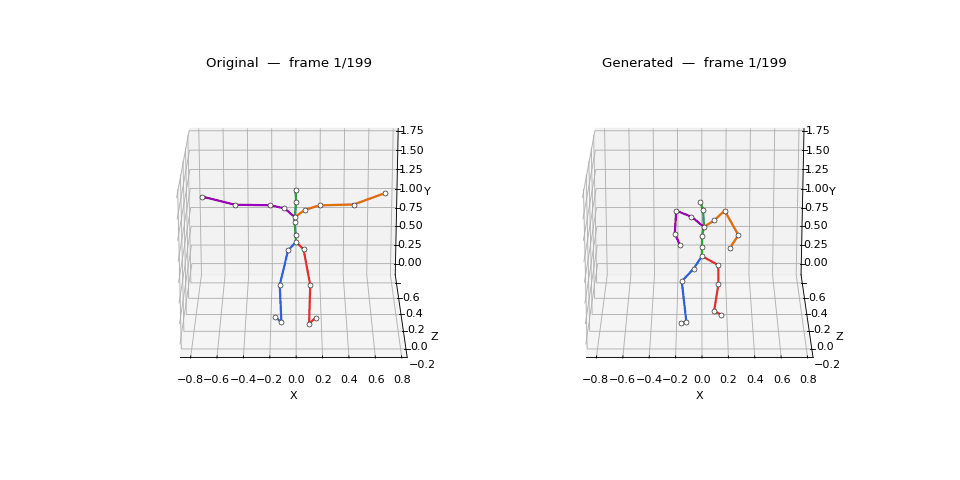

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import PillowWriter
from tqdm.auto import tqdm
from IPython.display import Image
from display import _draw_on_ax, _compute_limits


def _feat_to_joints(feat: np.ndarray) -> np.ndarray:
    T = feat.shape[0]
    root = np.stack([np.zeros(T), feat[:, 3], np.zeros(T)], axis=1)[:, np.newaxis]
    joints_1_21 = feat[:, 4:67].reshape(T, 21, 3)
    return np.concatenate([root, joints_1_21], axis=1)  # [T, 22, 3]


joints_orig = _feat_to_joints(feat_orig)
joints_gen  = _feat_to_joints(feat_gen)

# shared limits keep both panels on the same scale
shared_limits = _compute_limits(np.concatenate([joints_orig, joints_gen], axis=0))
T_anim = len(joints_orig)

output_gif = ROOT / 'models' / 'generated_animation.gif'

fig = plt.figure(figsize=(12, 6))
ax_orig = fig.add_subplot(121, projection='3d')
ax_gen  = fig.add_subplot(122, projection='3d')

writer = PillowWriter(fps=20)
with writer.saving(fig, str(output_gif), dpi=80):
    for i in tqdm(range(T_anim), desc='Rendering', unit='frame'):
        ax_orig.cla()
        ax_gen.cla()
        _draw_on_ax(ax_orig, joints_orig[i],
                    title=f'Original  —  frame {i + 1}/{T_anim}',
                    limits=shared_limits)
        _draw_on_ax(ax_gen,  joints_gen[i],
                    title=f'Generated  —  frame {i + 1}/{T_anim}',
                    limits=shared_limits)
        writer.grab_frame()

plt.close(fig)
print(f'Saved → {output_gif}')
Image(filename=str(output_gif))
